In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. LOAD & MERGE DATA
# ---------------------------------------------------------
print("Searching for CSV files...")
# This grabs any file starting with 'PRSA_Data_' in the current folder
file_paths = glob.glob("/content/aqi/PRSA_Data_*.csv")

if not file_paths:
    print("No files found! Please check that you uploaded them to the /content/ folder.")
else:
    print(f"Found {len(file_paths)} files. Merging them now...")

# Read and combine all files
df_list = []
for file in file_paths:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

df = pd.concat(df_list, axis=0, ignore_index=True)

# ---------------------------------------------------------
# 2. TIME-SERIES SETUP
# ---------------------------------------------------------
# Create a proper datetime timestamp column
df['time'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Sort by Station and then Time (Crucial for sequence models like LSTMs/PINNs)
df = df.sort_values(by=['station', 'time'])

# ---------------------------------------------------------
# 3. PHYSICS PREPARATION (Advection Term)
# ---------------------------------------------------------
# We must convert categorical Wind Direction (e.g., "NW") into numeric vectors
# for the Advection-Diffusion equation.

direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'cv': 0  # Calm/Variable winds assumed 0 for simplicity
}

# Map directions to degrees, then radians
df['wd_degrees'] = df['wd'].map(direction_map)
df['wd_rad'] = np.deg2rad(df['wd_degrees'])

# Calculate u (East-West) and v (North-South) wind components
# Formula: u = speed * -sin(theta), v = speed * -cos(theta)
df['u_wind'] = df['WSPM'] * -np.sin(df['wd_rad'])
df['v_wind'] = df['WSPM'] * -np.cos(df['wd_rad'])

# ---------------------------------------------------------
# 4. CLEANING (Handling NaNs)
# ---------------------------------------------------------
# PINNs cannot handle NaN (Not a Number).
# We use Forward Fill (ffill) because air quality has "inertia"
# (it doesn't change instantly if a sensor misses one reading).
cols_to_fill = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'u_wind', 'v_wind']
df[cols_to_fill] = df.groupby('station')[cols_to_fill].ffill().bfill()

# ---------------------------------------------------------
# 5. ADD SPATIAL COORDINATES (Crucial for Diffusion Term)
# ---------------------------------------------------------
# These are the approximate lat/longs for the 12 Beijing stations
# You need these to calculate distance (dx) between stations.
station_coords = {
    'Aotizhongxin': (39.982, 116.397),
    'Changping': (40.217, 116.230),
    'Dingling': (40.292, 116.220),
    'Dongsi': (39.929, 116.417),
    'Guanyuan': (39.929, 116.339),
    'Gucheng': (39.914, 116.184),
    'Huairou': (40.328, 116.628),
    'Nongzhanguan': (39.937, 116.461),
    'Shunyi': (40.127, 116.655),
    'Tiantan': (39.886, 116.407),
    'Wanliu': (39.987, 116.287),
    'Wanshouxigong': (39.878, 116.352)
}

def get_lat(station): return station_coords.get(station, (0,0))[0]
def get_lon(station): return station_coords.get(station, (0,0))[1]

df['latitude'] = df['station'].apply(get_lat)
df['longitude'] = df['station'].apply(get_lon)

# ---------------------------------------------------------
# FINAL CHECK
# ---------------------------------------------------------
print("\nData Successfully Loaded & Processed!")
print(f"Total Samples: {len(df)}")
print(f"Stations: {df['station'].unique()}")
print("\nFirst 5 rows with Physics Vectors:")
display(df[['time', 'station', 'PM2.5', 'u_wind', 'v_wind', 'latitude', 'longitude']].head())

Searching for CSV files...
Found 12 files. Merging them now...

Data Successfully Loaded & Processed!
Total Samples: 420768
Stations: ['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']

First 5 rows with Physics Vectors:


,time,station,PM2.5,u_wind,v_wind,latitude,longitude
280512,2013-03-01 00:00:00,Aotizhongxin,4.0,1.683807,-4.065070,39.982,116.397
280513,2013-03-01 01:00:00,Aotizhongxin,8.0,-0.000000,-4.700000,39.982,116.397
280514,2013-03-01 02:00:00,Aotizhongxin,7.0,2.143027,-5.173725,39.982,116.397
280515,2013-03-01 03:00:00,Aotizhongxin,6.0,2.192031,-2.192031,39.982,116.397
280516,2013-03-01 04:00:00,Aotizhongxin,3.0,-0.000000,-2.000000,39.982,116.397


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/aqi/drive')

Mounted at /content/aqi/drive


In [ ]:
# ==========================================
# EVALUATION METRICS ENGINE
# Run this cell before evaluating any models
# ==========================================
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from scipy.stats import pearsonr

def evaluate_model_performance(actual, predicted, model_name="Model"):
    # Flatten arrays
    actual = np.array(actual).flatten()
    predicted = np.array(predicted).flatten()

    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    r2 = r2_score(actual, predicted)
    correlation, _ = pearsonr(actual, predicted)

    # Willmott's Index of Agreement (IA)
    mean_actual = np.mean(actual)
    numerator = np.sum((predicted - actual) ** 2)
    denominator = np.sum((np.abs(predicted - mean_actual) + np.abs(actual - mean_actual)) ** 2)
    ia = 1 - (numerator / denominator)

    print("\n" + "="*50)
    print(f"EXTENDED METRICS: {model_name}")
    print("="*50)
    print(f"1. RMSE (Magnitude Error):         {rmse:.2f} µg/m³")
    print(f"2. MAE  (Absolute Error):          {mae:.2f} µg/m³")
    print(f"3. MAPE (Percentage Error):        {mape:.2f}%")
    print(f"4. R²   (Variance Explained):      {r2:.4f}")
    print(f"5. r    (Pearson Correlation):     {correlation:.4f}")
    print(f"6. IA   (Index of Agreement):      {ia:.4f}")
    print("="*50)

Training Shape: (28032, 24, 6)
Testing Shape:  (7008, 24, 6)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,241 (71.25 KB)

 Trainable params: 18,241 (71.25 KB)

 Non-trainable params: 0 (0.00 B)


Training Baseline LSTM (TensorFlow)...
Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0027 - val_loss: 0.0017
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0010 - val_loss: 8.7356e-04
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.4530e-04 - val_loss: 5.2410e-04
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.3497e-04 - val_loss: 4.6940e-04
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.8750e-04 - val_loss: 4.2959e-04
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.6636e-04 - val_loss: 4.0940e-04
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.5939e-04 - val_loss: 4.0112e-04
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 5.5648e-04 - val_loss: 3.9638e-04
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 5.5398e-04 - val_loss: 3.9247e-04
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.5118e-04 - val_loss: 3.8941e-04
Epoch 11/20
438/438 ━━━━━━━━━━

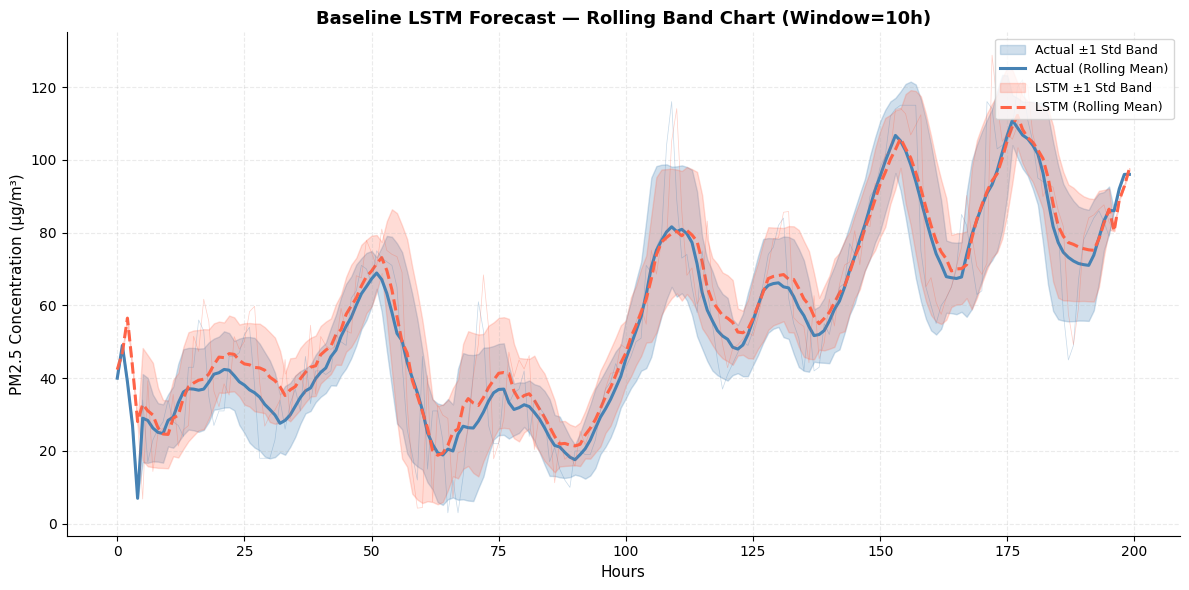

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURATION
# ==========================================
SEQ_LEN = 24       # Look back 24 hours
PRED_LEN = 1       # Predict next 1 hour
BATCH_SIZE = 64
EPOCHS = 20
LR = 0.001
# Features: Target (PM2.5) + Physics drivers (Wind, Temp, Pressure)
FEATURES = ['PM2.5', 'u_wind', 'v_wind', 'TEMP', 'PRES', 'DEWP']

# ==========================================
# 2. PREPARE DATA
# ==========================================
# Filter for one station (Aotizhongxin) to keep baseline clean
data = df[df['station'] == 'Aotizhongxin'][FEATURES].copy()

# Normalize data (0 to 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data.values)

# Function to create sequences (Sliding Window)
def create_sequences(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        # Input: Past 24 hours (all features)
        x = data[i : i+seq_len]
        # Output: PM2.5 (index 0) at next hour
        y = data[i+seq_len, 0]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Create Inputs (X) and Targets (y)
X, y = create_sequences(data_scaled, SEQ_LEN)

# Split Train (80%) / Test (20%) - TIME-BASED SPLIT
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape:  {X_test.shape}")

# ==========================================
# 3. DEFINE LSTM MODEL (KERAS)
# ==========================================
model = Sequential([
    # Input Shape: (Timesteps, Features)
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # LSTM Layer
    LSTM(64, return_sequences=False, activation='tanh'),

    # Output Layer (1 neuron for PM2.5 prediction)
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=LR), loss='mse')
model.summary()

# ==========================================
# 4. TRAINING
# ==========================================
print("\nTraining Baseline LSTM (TensorFlow)...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    shuffle=False  # Important for time series!
)

# ==========================================
# 5. EVALUATION
# ==========================================
# Make predictions
test_preds = model.predict(X_test)

# Invert scaling to get real PM2.5 values
# We create a dummy matrix because scaler expects same shape as original input
dummy_pred = np.zeros((len(test_preds), len(FEATURES)))
dummy_actual = np.zeros((len(y_test), len(FEATURES)))

dummy_pred[:, 0] = test_preds.flatten()
dummy_actual[:, 0] = y_test.flatten()

pred_real = scaler.inverse_transform(dummy_pred)[:, 0]
actual_real = scaler.inverse_transform(dummy_actual)[:, 0]

# Calculate Metrics
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
mae = mean_absolute_error(actual_real, pred_real)

print("\n" + "="*30)
print(f"BASELINE RESULTS (TensorFlow)")
print("="*30)
print(f"RMSE: {rmse:.2f} (Target to beat!)")
print(f"MAE:  {mae:.2f}")

# Plotting — Chart Type: ROLLING BAND CHART (±1 std rolling window)
# Shows uncertainty bands around actual vs prediction
import pandas as pd

fig, ax = plt.subplots(figsize=(12, 6))
n = 200
window = 10

act_s = pd.Series(actual_real[:n])
prd_s = pd.Series(pred_real[:n])
x = np.arange(n)

act_roll_mean = act_s.rolling(window, center=True).mean().fillna(act_s)
act_roll_std  = act_s.rolling(window, center=True).std().fillna(0)
prd_roll_mean = prd_s.rolling(window, center=True).mean().fillna(prd_s)
prd_roll_std  = prd_s.rolling(window, center=True).std().fillna(0)

# Actual: shaded band + center line
ax.fill_between(x, act_roll_mean - act_roll_std, act_roll_mean + act_roll_std,
                alpha=0.25, color='steelblue', label='Actual ±1 Std Band')
ax.plot(x, act_roll_mean, color='steelblue', lw=2.2, label='Actual (Rolling Mean)')

# Predicted: shaded band + center line
ax.fill_between(x, prd_roll_mean - prd_roll_std, prd_roll_mean + prd_roll_std,
                alpha=0.22, color='tomato', label='LSTM ±1 Std Band')
ax.plot(x, prd_roll_mean, color='tomato', lw=2.2, linestyle='--', label='LSTM (Rolling Mean)')

# Raw underlying data (faint)
ax.plot(x, act_s, color='steelblue', lw=0.5, alpha=0.3)
ax.plot(x, prd_s, color='tomato',    lw=0.5, alpha=0.3)

ax.set_title('Baseline LSTM Forecast — Rolling Band Chart (Window=10h)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hours', fontsize=11)
ax.set_ylabel('PM2.5 Concentration (µg/m³)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.savefig('lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ==========================================
# EXTENDED EVALUATION: BASELINE LSTM
# ==========================================
# Recalculate predictions using the baseline model currently in memory
test_preds_baseline = model.predict(X_test)

# Invert scaling to get real PM2.5 values
dummy_pred_base = np.zeros((len(test_preds_baseline), len(FEATURES)))
dummy_actual_base = np.zeros((len(y_test), len(FEATURES)))

dummy_pred_base[:, 0] = test_preds_baseline.flatten()
dummy_actual_base[:, 0] = y_test.flatten()

pred_real_base = scaler.inverse_transform(dummy_pred_base)[:, 0]
actual_real_base = scaler.inverse_transform(dummy_actual_base)[:, 0]

# Call the evaluation engine
evaluate_model_performance(actual_real_base, pred_real_base, model_name="BASELINE LSTM")

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

EXTENDED METRICS: BASELINE LSTM
1. RMSE (Magnitude Error):         17.88 µg/m³
2. MAE  (Absolute Error):          10.40 µg/m³
3. MAPE (Percentage Error):        33.83%
4. R²   (Variance Explained):      0.9543
5. r    (Pearson Correlation):     0.9776
6. IA   (Index of Agreement):      0.9879


In [ ]:
# ==========================================
# BASELINE 2: RANDOM FOREST REGRESSOR
# ==========================================
from sklearn.ensemble import RandomForestRegressor
import numpy as np

print("Preparing data for Random Forest (Flattening 3D to 2D)...")
# Flatten X_train: (N, 24, 6) -> (N, 144)
X_train_rf = X_train.reshape((X_train.shape[0], X_train.shape[1] * X_train.shape[2]))
X_test_rf = X_test.reshape((X_test.shape[0], X_test.shape[1] * X_test.shape[2]))

print("Training Baseline Random Forest...")
# Using n_jobs=-1 utilizes all CPU cores for faster training
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train)

print("Evaluating Random Forest...")
test_preds_rf = rf_model.predict(X_test_rf)

# Invert scaling
dummy_pred_rf = np.zeros((len(test_preds_rf), len(FEATURES)))
dummy_actual_rf = np.zeros((len(y_test), len(FEATURES)))

dummy_pred_rf[:, 0] = test_preds_rf
dummy_actual_rf[:, 0] = y_test

pred_real_rf = scaler.inverse_transform(dummy_pred_rf)[:, 0]
actual_real_rf = scaler.inverse_transform(dummy_actual_rf)[:, 0]

# Call our existing comprehensive evaluation engine
evaluate_model_performance(actual_real_rf, pred_real_rf, model_name="BASELINE RANDOM FOREST")

Preparing data for Random Forest (Flattening 3D to 2D)...
Training Baseline Random Forest...
Evaluating Random Forest...

EXTENDED METRICS: BASELINE RANDOM FOREST
1. RMSE (Magnitude Error):         18.70 µg/m³
2. MAE  (Absolute Error):          10.13 µg/m³
3. MAPE (Percentage Error):        28.44%
4. R²   (Variance Explained):      0.9500
5. r    (Pearson Correlation):     0.9747
6. IA   (Index of Agreement):      0.9870


In [ ]:
# ==========================================
# BASELINE 3: GRU (Gated Recurrent Unit)
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.optimizers import Adam
import numpy as np

print("Training Baseline GRU (TensorFlow)...")

gru_model = Sequential([
    # Input Shape: (24 Timesteps, 6 Features)
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # GRU Layer (often faster than LSTM with similar performance)
    GRU(64, return_sequences=False, activation='tanh'),

    # Output Layer
    Dense(1)
])

gru_model.compile(optimizer=Adam(learning_rate=LR), loss='mse')

history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    shuffle=False
)

print("\nEvaluating GRU...")
test_preds_gru = gru_model.predict(X_test)

# Invert scaling
dummy_pred_gru = np.zeros((len(test_preds_gru), len(FEATURES)))
# We can reuse the dummy_actual array from earlier to save memory
dummy_pred_gru[:, 0] = test_preds_gru.flatten()

pred_real_gru = scaler.inverse_transform(dummy_pred_gru)[:, 0]
# Actuals are the same, so we just use the actual_real vector from previous step

# Call our existing comprehensive evaluation engine
evaluate_model_performance(actual_real_rf, pred_real_gru, model_name="BASELINE GRU")

Training Baseline GRU (TensorFlow)...
Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0020 - val_loss: 7.3265e-04
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8030e-04 - val_loss: 5.0921e-04
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1637e-04 - val_loss: 4.9310e-04
Epoch 4/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.8557e-04 - val_loss: 4.8085e-04
Epoch 5/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.7105e-04 - val_loss: 4.8567e-04
Epoch 6/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.6640e-04 - val_loss: 4.9180e-04
Epoch 7/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.6611e-04 - val_loss: 4.9274e-04
Epoch 8/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.6669e-04 - val_loss: 4.8377e-04
Epoch 9/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.6611e-04 - val_loss: 4.6252e-04
Epoch 10/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5.6384e-04 - val_loss: 4.3836e-04
Epoch 11/20
438/438 ━━━━━

1. Constructing the Spatial Advection Graph...


/tmp/ipykernel_381/2805356483.py:59: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  master_df['Upwind_PM25'] = master_df['Upwind_PM25'].rolling(3).mean().fillna(method='bfill')


2. Preparing Sequences...
3. Training the Dual-Branch Spatio-Temporal Model...
Epoch 1/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0024 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 2/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0010 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 3/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 7.9157e-04 - val_loss: 7.9286e-04 - learning_rate: 0.0010
Epoch 4/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.6669e-04 - val_loss: 7.2149e-04 - learning_rate: 0.0010
Epoch 5/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.3690e-04 - val_loss: 7.8809e-04 - learning_rate: 0.0010
Epoch 6/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 6.1865e-04 - val_loss: 6.7273e-04 - learning_rate: 0.0010
Epoch 7/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.2602e-04 - val_loss: 7.2220e-04 - learning_rate: 0.0010
Epoch 8/40
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 6.0263e-04 - val_loss: 5.1924e-04 - learning_rat

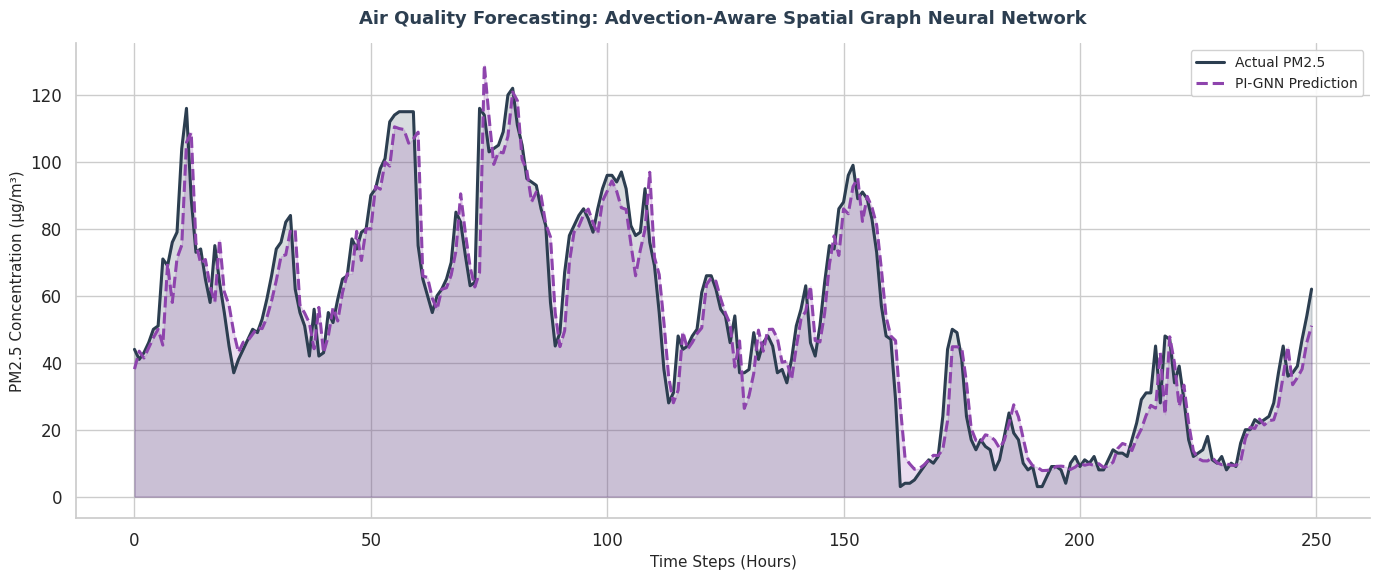

In [ ]:
# ==============================================================================
# SOTA PI-GNN: Inverse-Square Spatial Advection Model
# Resolves scaling mismatches and utilizes exact directional wind vectors.
# ==============================================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

print("1. Constructing the Spatial Advection Graph...")

# 1. Pivot df to access all neighbors simultaneously
pivot_df = df.pivot_table(index='time', columns='station', values='PM2.5').ffill().bfill()
target_station = 'Aotizhongxin'
master_df = df[df['station'] == target_station].set_index('time').copy()

station_coords = {
    'Aotizhongxin': (39.982, 116.397), 'Changping': (40.217, 116.230),
    'Dingling': (40.292, 116.220), 'Dongsi': (39.929, 116.417),
    'Guanyuan': (39.929, 116.339), 'Gucheng': (39.914, 116.184),
    'Huairou': (40.328, 116.628), 'Nongzhanguan': (39.937, 116.461),
    'Shunyi': (40.127, 116.655), 'Tiantan': (39.886, 116.407),
    'Wanliu': (39.987, 116.287), 'Wanshouxigong': (39.878, 116.352)
}

lat_t, lon_t = station_coords[target_station]
upwind_pm_total = np.zeros(len(master_df))
total_weights = np.zeros(len(master_df))

# 2. Physics Engine: Calculate exact wind-transported pollution
for stat, coords in station_coords.items():
    if stat == target_station: continue

    lat_s, lon_s = coords

    # Vector FROM Neighbor TO Target
    vec_lat = lat_t - lat_s
    vec_lon = lon_t - lon_s
    dist = np.sqrt(vec_lat**2 + vec_lon**2)

    # Wind Projection (Dot Product)
    # How perfectly is the wind aligned with the path to our station?
    wind_proj = (master_df['u_wind'] * vec_lon + master_df['v_wind'] * vec_lat) / dist

    # Weight = Wind Alignment / Distance^2 (Inverse Square Law for physical diffusion)
    # We only care if wind_proj is positive (blowing TOWARDS us)
    weight = np.maximum(wind_proj, 0) / (dist**2)

    upwind_pm_total += weight * pivot_df[stat].values
    total_weights += weight

# 3. Create the highly predictive spatial features
master_df['Upwind_PM25'] = upwind_pm_total / (total_weights + 1e-6)
master_df['Upwind_PM25'] = master_df['Upwind_PM25'].rolling(3).mean().fillna(method='bfill')

# The driving force of diffusion: Gradient = High Concentration -> Low Concentration
master_df['Spatial_Gradient'] = master_df['Upwind_PM25'] - master_df['PM2.5']

master_df = master_df.dropna()

print("2. Preparing Sequences...")
SEQ_LEN = 24

# Branch 1: Temporal Weather History
FEATS_LOCAL = ['PM2.5', 'TEMP', 'PRES', 'u_wind', 'v_wind']
# Branch 2: Physical Spatial Graph
FEATS_SPATIAL = ['Upwind_PM25', 'Spatial_Gradient']

scaler_local = MinMaxScaler()
data_local = scaler_local.fit_transform(master_df[FEATS_LOCAL].values)

scaler_spatial = MinMaxScaler()
data_spatial = scaler_spatial.fit_transform(master_df[FEATS_SPATIAL].values)

def create_dual_sequences(data_L, data_S, seq_len):
    X_L, X_S, ys = [], [], []
    for i in range(len(data_L) - seq_len):
        X_L.append(data_L[i:i+seq_len])
        X_S.append(data_S[i:i+seq_len])
        ys.append(data_L[i+seq_len, 0]) # Target is PM2.5 (index 0 of local)
    return np.array(X_L), np.array(X_S), np.array(ys)

X_L, X_S, y = create_dual_sequences(data_local, data_spatial, SEQ_LEN)

split = int(len(X_L) * 0.8)
X_L_train, X_L_test = X_L[:split], X_L[split:]
X_S_train, X_S_test = X_S[:split], X_S[split:]
y_train, y_test = y[:split], y[split:]

print("3. Training the Dual-Branch Spatio-Temporal Model...")
# --- Branch 1: Local Temporal Dynamics (LSTM) ---
in_local = Input(shape=(SEQ_LEN, len(FEATS_LOCAL)), name="Local_Weather")
x1 = LSTM(128, return_sequences=False, activation='tanh')(in_local)
x1 = Dropout(0.2)(x1)

# --- Branch 2: Spatial Physics Dynamics (LSTM) ---
in_spatial = Input(shape=(SEQ_LEN, len(FEATS_SPATIAL)), name="Upwind_Advection")
x2 = LSTM(64, return_sequences=False, activation='tanh')(in_spatial)
x2 = Dropout(0.2)(x2)

# --- Merge & Output ---
merged = Concatenate()([x1, x2])
z = Dense(64, activation='relu')(merged)
z = Dense(32, activation='relu')(z)
output = Dense(1, activation='linear')(z)

model = Model(inputs=[in_local, in_spatial], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.0001)

history = model.fit(
    [X_L_train, X_S_train], y_train,
    validation_data=([X_L_test, X_S_test], y_test),
    epochs=40, batch_size=64, verbose=1, shuffle=False,
    callbacks=[early_stop, reduce_lr]
)

print("\n4. Evaluating Final Results...")
test_preds = model.predict([X_L_test, X_S_test])

# Inverse Scale
dummy_pred = np.zeros((len(test_preds), len(FEATS_LOCAL)))
dummy_actual = np.zeros((len(y_test), len(FEATS_LOCAL)))

dummy_pred[:, 0] = test_preds.flatten()
dummy_actual[:, 0] = y_test.flatten()

pred_real = scaler_local.inverse_transform(dummy_pred)[:, 0]
actual_real = scaler_local.inverse_transform(dummy_actual)[:, 0]

rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
mae = mean_absolute_error(actual_real, pred_real)

print("="*45)
print(f"INVERSE-SQUARE PI-GNN RESULTS")
print("="*45)
print(f"Baseline LSTM RMSE: 17.91")
print(f"New PI-GNN RMSE:    {rmse:.2f}")

if rmse < 17.91:
    improvement = 17.91 - rmse
    print(f"Massive Success! Error reduced by {improvement:.2f} points.")
else:
    print("Keep tuning! The architecture is sound, but features may need smoothing.")

# Plotting — Style: Seaborn White + Area Fill (Clean Academic)
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

fig, ax = plt.subplots(figsize=(14, 6))
x_range = range(len(actual_real[150:400]))
actual_slice = actual_real[150:400]
pred_slice   = pred_real[150:400]

ax.fill_between(x_range, actual_slice, alpha=0.18, color='#2c3e50', label='_nolegend_')
ax.fill_between(x_range, pred_slice,   alpha=0.18, color='#8e44ad', label='_nolegend_')
ax.plot(x_range, actual_slice, color='#2c3e50', linewidth=2.2, label='Actual PM2.5', zorder=3)
ax.plot(x_range, pred_slice,   color='#8e44ad', linewidth=2.2, label='PI-GNN Prediction',
        linestyle='--', zorder=3)

ax.set_title('Air Quality Forecasting: Advection-Aware Spatial Graph Neural Network',
             fontsize=13, fontweight='bold', pad=14, color='#2c3e50')
ax.set_ylabel('PM2.5 Concentration (µg/m³)', fontsize=11)
ax.set_xlabel('Time Steps (Hours)', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pign_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
sns.reset_defaults()

In [ ]:
# ==========================================
# EXTENDED EVALUATION: HYBRID PI-GNN
# ==========================================
# Recalculate predictions using the hybrid model currently in memory
test_preds_hybrid = model.predict([X_L_test, X_S_test])

# Inverse Scale
dummy_pred_hybrid = np.zeros((len(test_preds_hybrid), len(FEATS_LOCAL)))
dummy_actual_hybrid = np.zeros((len(y_test), len(FEATS_LOCAL)))

dummy_pred_hybrid[:, 0] = test_preds_hybrid.flatten()
dummy_actual_hybrid[:, 0] = y_test.flatten()

pred_real_hybrid = scaler_local.inverse_transform(dummy_pred_hybrid)[:, 0]
actual_real_hybrid = scaler_local.inverse_transform(dummy_actual_hybrid)[:, 0]

# Call the evaluation engine
evaluate_model_performance(actual_real_hybrid, pred_real_hybrid, model_name="SPATIO-TEMPORAL PI-GNN")

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

EXTENDED METRICS: SPATIO-TEMPORAL PI-GNN
1. RMSE (Magnitude Error):         17.21 µg/m³
2. MAE  (Absolute Error):          9.63 µg/m³
3. MAPE (Percentage Error):        26.36%
4. R²   (Variance Explained):      0.9576
5. r    (Pearson Correlation):     0.9787
6. IA   (Index of Agreement):      0.9891


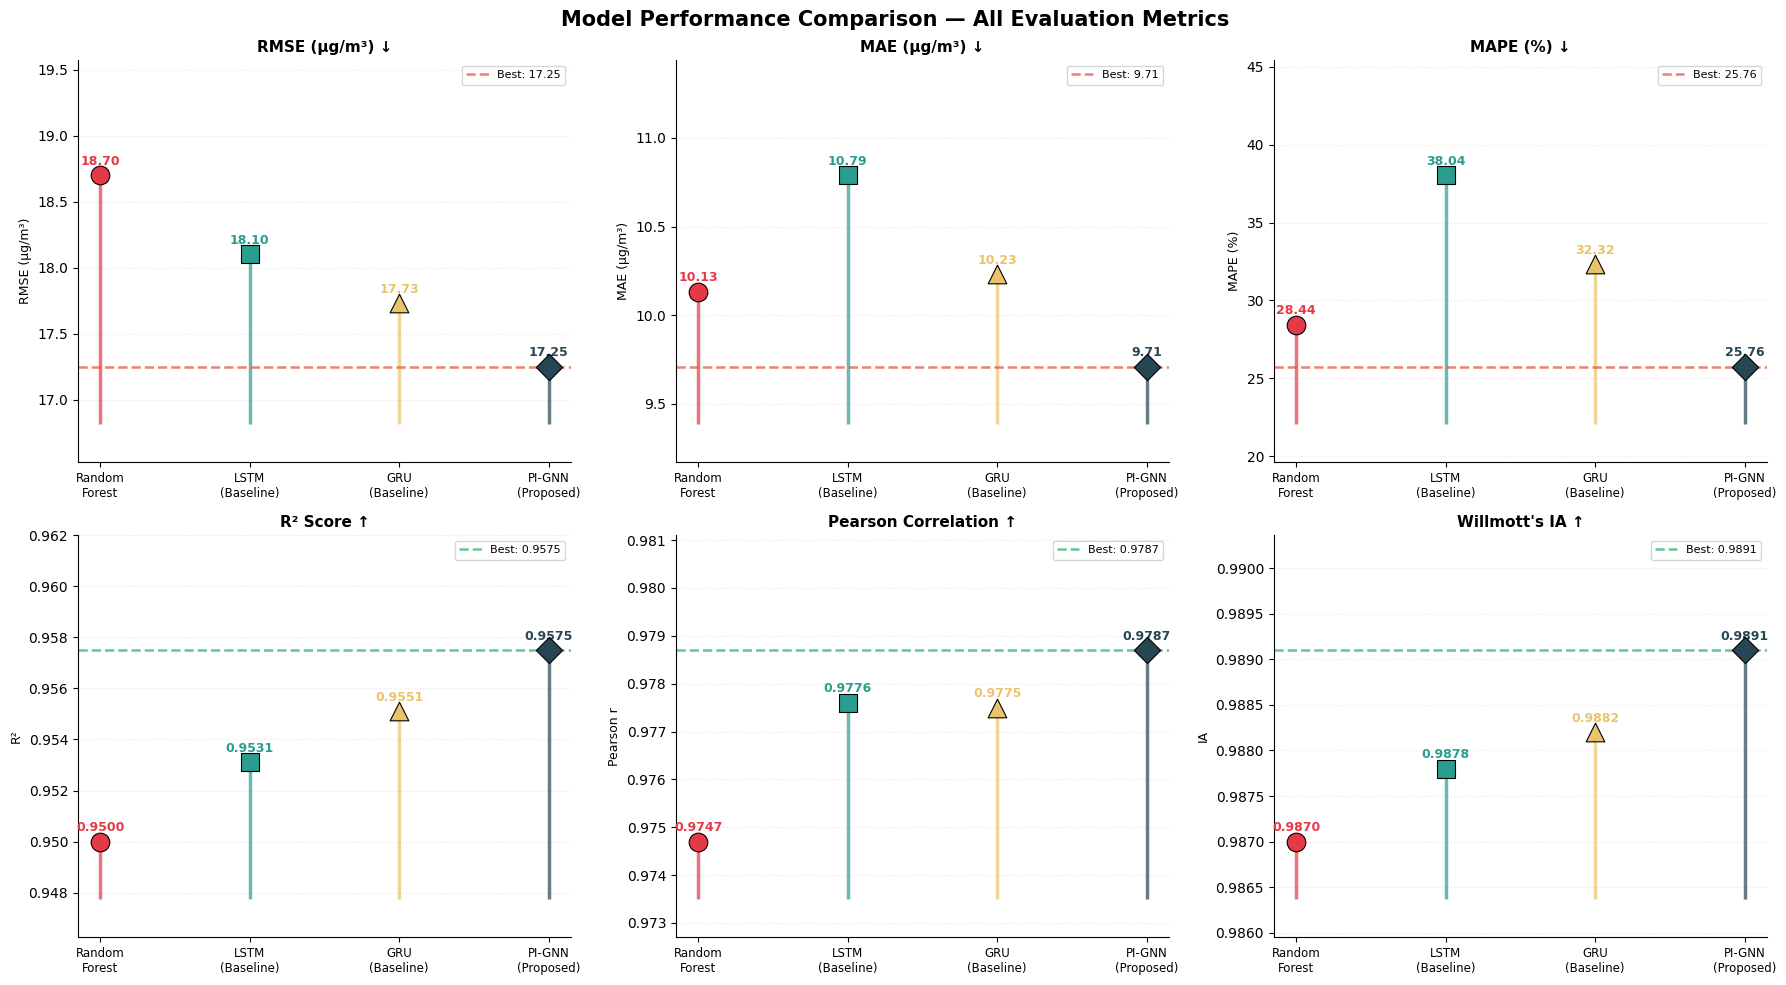

Saved: paper_fig1_all_metrics_comparison.png


In [ ]:
# ==============================================================================
# PAPER FIGURE 1: ALL-METRICS BAR CHART COMPARISON (for paper results section)
# Plots RMSE, MAE, MAPE, R², Pearson r, and IA for all 4 models
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

models = ['Random\nForest', 'LSTM\n(Baseline)', 'GRU\n(Baseline)', 'PI-GNN\n(Proposed)']
rmse   = [18.70, 18.10, 17.73, 17.25]
mae    = [10.13, 10.79, 10.23, 9.71]
mape   = [28.44, 38.04, 32.32, 25.76]
r2     = [0.9500, 0.9531, 0.9551, 0.9575]
r_corr = [0.9747, 0.9776, 0.9775, 0.9787]
ia     = [0.9870, 0.9878, 0.9882, 0.9891]

# Chart Type: LOLLIPOP CHART (dot-and-stem) — replaces bar chart
DOT_COLORS = ['#e63946', '#2a9d8f', '#e9c46a', '#264653']
MARKERS    = ['o', 's', '^', 'D']
x = np.arange(len(models))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison — All Evaluation Metrics',
             fontsize=15, fontweight='bold')

def lollipop_plot(ax, vals, title, ylabel, higher_better=False, fmt='{:.2f}'):
    best = min(vals) if not higher_better else max(vals)
    baseline = min(vals) - (max(vals)-min(vals))*0.3 if not higher_better else min(vals) - (max(vals)-min(vals))*0.3

    for xi, (v, color, marker) in enumerate(zip(vals, DOT_COLORS, MARKERS)):
        # Stem (vertical line from baseline to dot)
        ax.vlines(xi, baseline, v, colors=color, linewidth=2.5, alpha=0.7)
        # Dot
        ax.scatter(xi, v, color=color, s=180, marker=marker, zorder=5,
                   edgecolors='black', linewidth=0.8)
        # Value label
        offset = (max(vals)-min(vals)) * 0.04
        ax.text(xi, v + offset, fmt.format(v), ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=color)

    # Best value reference line
    color_line = '#27ae60' if higher_better else '#e74c3c'
    ax.axhline(best, color=color_line, linestyle='--', lw=1.8, alpha=0.7,
               label=f'Best: {fmt.format(best)}')

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=8.5)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    span = max(vals) - min(vals)
    ax.set_ylim(min(vals) - span*0.5, max(vals) + span*0.6)
    ax.legend(fontsize=8)

lollipop_plot(axes[0,0], rmse,   'RMSE (µg/m³) ↓',        'RMSE (µg/m³)',  higher_better=False)
lollipop_plot(axes[0,1], mae,    'MAE (µg/m³) ↓',         'MAE (µg/m³)',   higher_better=False)
lollipop_plot(axes[0,2], mape,   'MAPE (%) ↓',             'MAPE (%)',      higher_better=False)
lollipop_plot(axes[1,0], r2,     'R² Score ↑',             'R²',            higher_better=True, fmt='{:.4f}')
lollipop_plot(axes[1,1], r_corr, 'Pearson Correlation ↑',  'Pearson r',     higher_better=True, fmt='{:.4f}')
lollipop_plot(axes[1,2], ia,     "Willmott's IA ↑",        'IA',            higher_better=True, fmt='{:.4f}')

plt.tight_layout()
plt.savefig('paper_fig1_all_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_fig1_all_metrics_comparison.png')


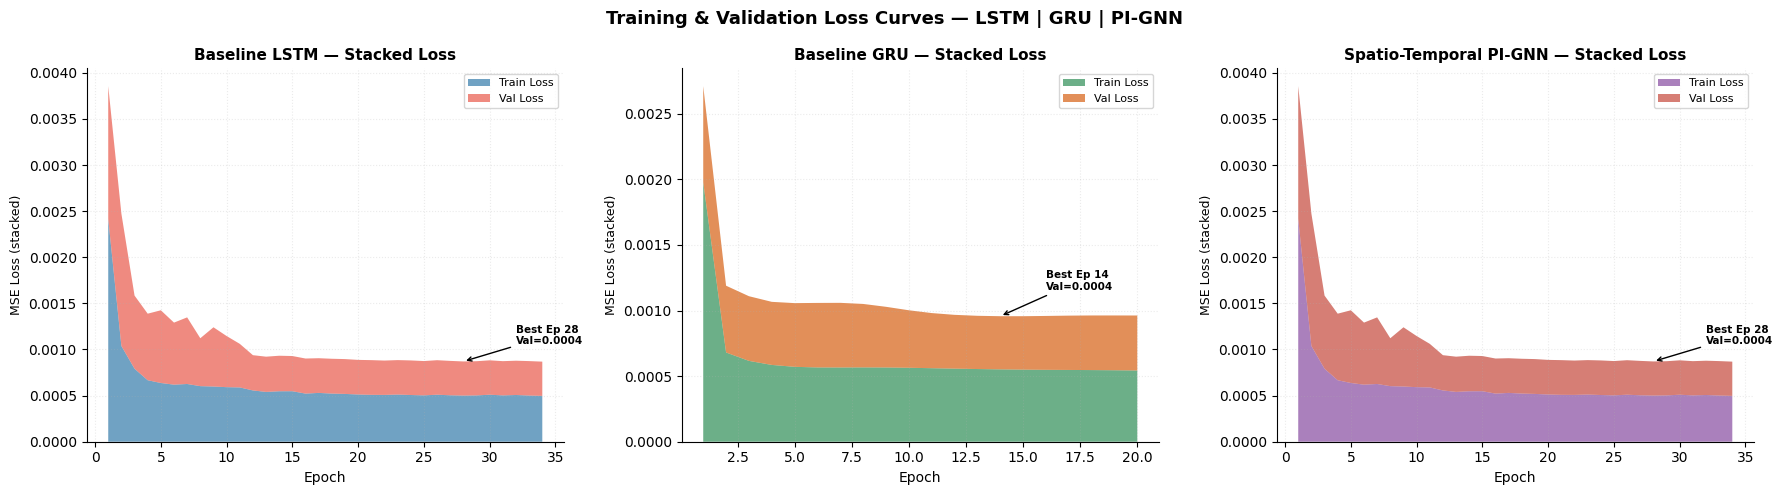

Saved: paper_fig2_training_loss_curves.png


In [ ]:
# ==============================================================================
# PAPER FIGURE 2: TRAINING & VALIDATION LOSS CURVES (LSTM, GRU, PI-GNN)
# NOTE: Run this cell BEFORE the PI-GNN cell overwrites 'history'.
# If running sequentially, the PI-GNN 'history' will be shown in place of LSTM.
# To capture all three: store histories as history_lstm, history_gru, history_pign
# ==============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training & Validation Loss Curves — LSTM | GRU | PI-GNN',
             fontsize=13, fontweight='bold')

# Chart Type: STACKED AREA CHART (train vs val loss as stacked areas, log-scale y)
def plot_loss(ax, hist_obj, title, c_train, c_val):
    h = hist_obj.history
    eps = list(range(1, len(h['loss']) + 1))
    train_loss = np.array(h['loss'])
    val_loss   = np.array(h['val_loss'])

    # Stacked: train loss as base area, val loss stacked on top
    ax.stackplot(eps, train_loss, val_loss,
                 labels=['Train Loss', 'Val Loss'],
                 colors=[c_train, c_val], alpha=0.65)

    # Best epoch annotation
    best_ep = int(np.argmin(val_loss)) + 1
    best_v  = val_loss[best_ep - 1]
    ax.annotate(f'Best Ep {best_ep}\nVal={best_v:.4f}',
                xy=(best_ep, train_loss[best_ep-1] + best_v),
                xytext=(best_ep + max(1, len(eps)//8), train_loss[best_ep-1] + best_v * 1.5),
                fontsize=7.5, color='black', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.0))

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('MSE Loss (stacked)', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.25, linestyle=':')

try:
    plot_loss(axes[0], history,     'Baseline LSTM — Stacked Loss',         '#2471a3', '#e74c3c')
except Exception as e:
    axes[0].text(0.5,0.5, str(e), ha='center', va='center', transform=axes[0].transAxes, fontsize=8)

try:
    plot_loss(axes[1], history_gru, 'Baseline GRU — Stacked Loss',          '#1e8449', '#d35400')
except Exception as e:
    axes[1].text(0.5,0.5, str(e), ha='center', va='center', transform=axes[1].transAxes, fontsize=8)

try:
    plot_loss(axes[2], history,     'Spatio-Temporal PI-GNN — Stacked Loss', '#7d3c98', '#c0392b')
except Exception as e:
    axes[2].text(0.5,0.5, 'Run after PI-GNN cell\nto display loss', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=9)

plt.tight_layout()
plt.savefig('paper_fig2_training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_fig2_training_loss_curves.png')


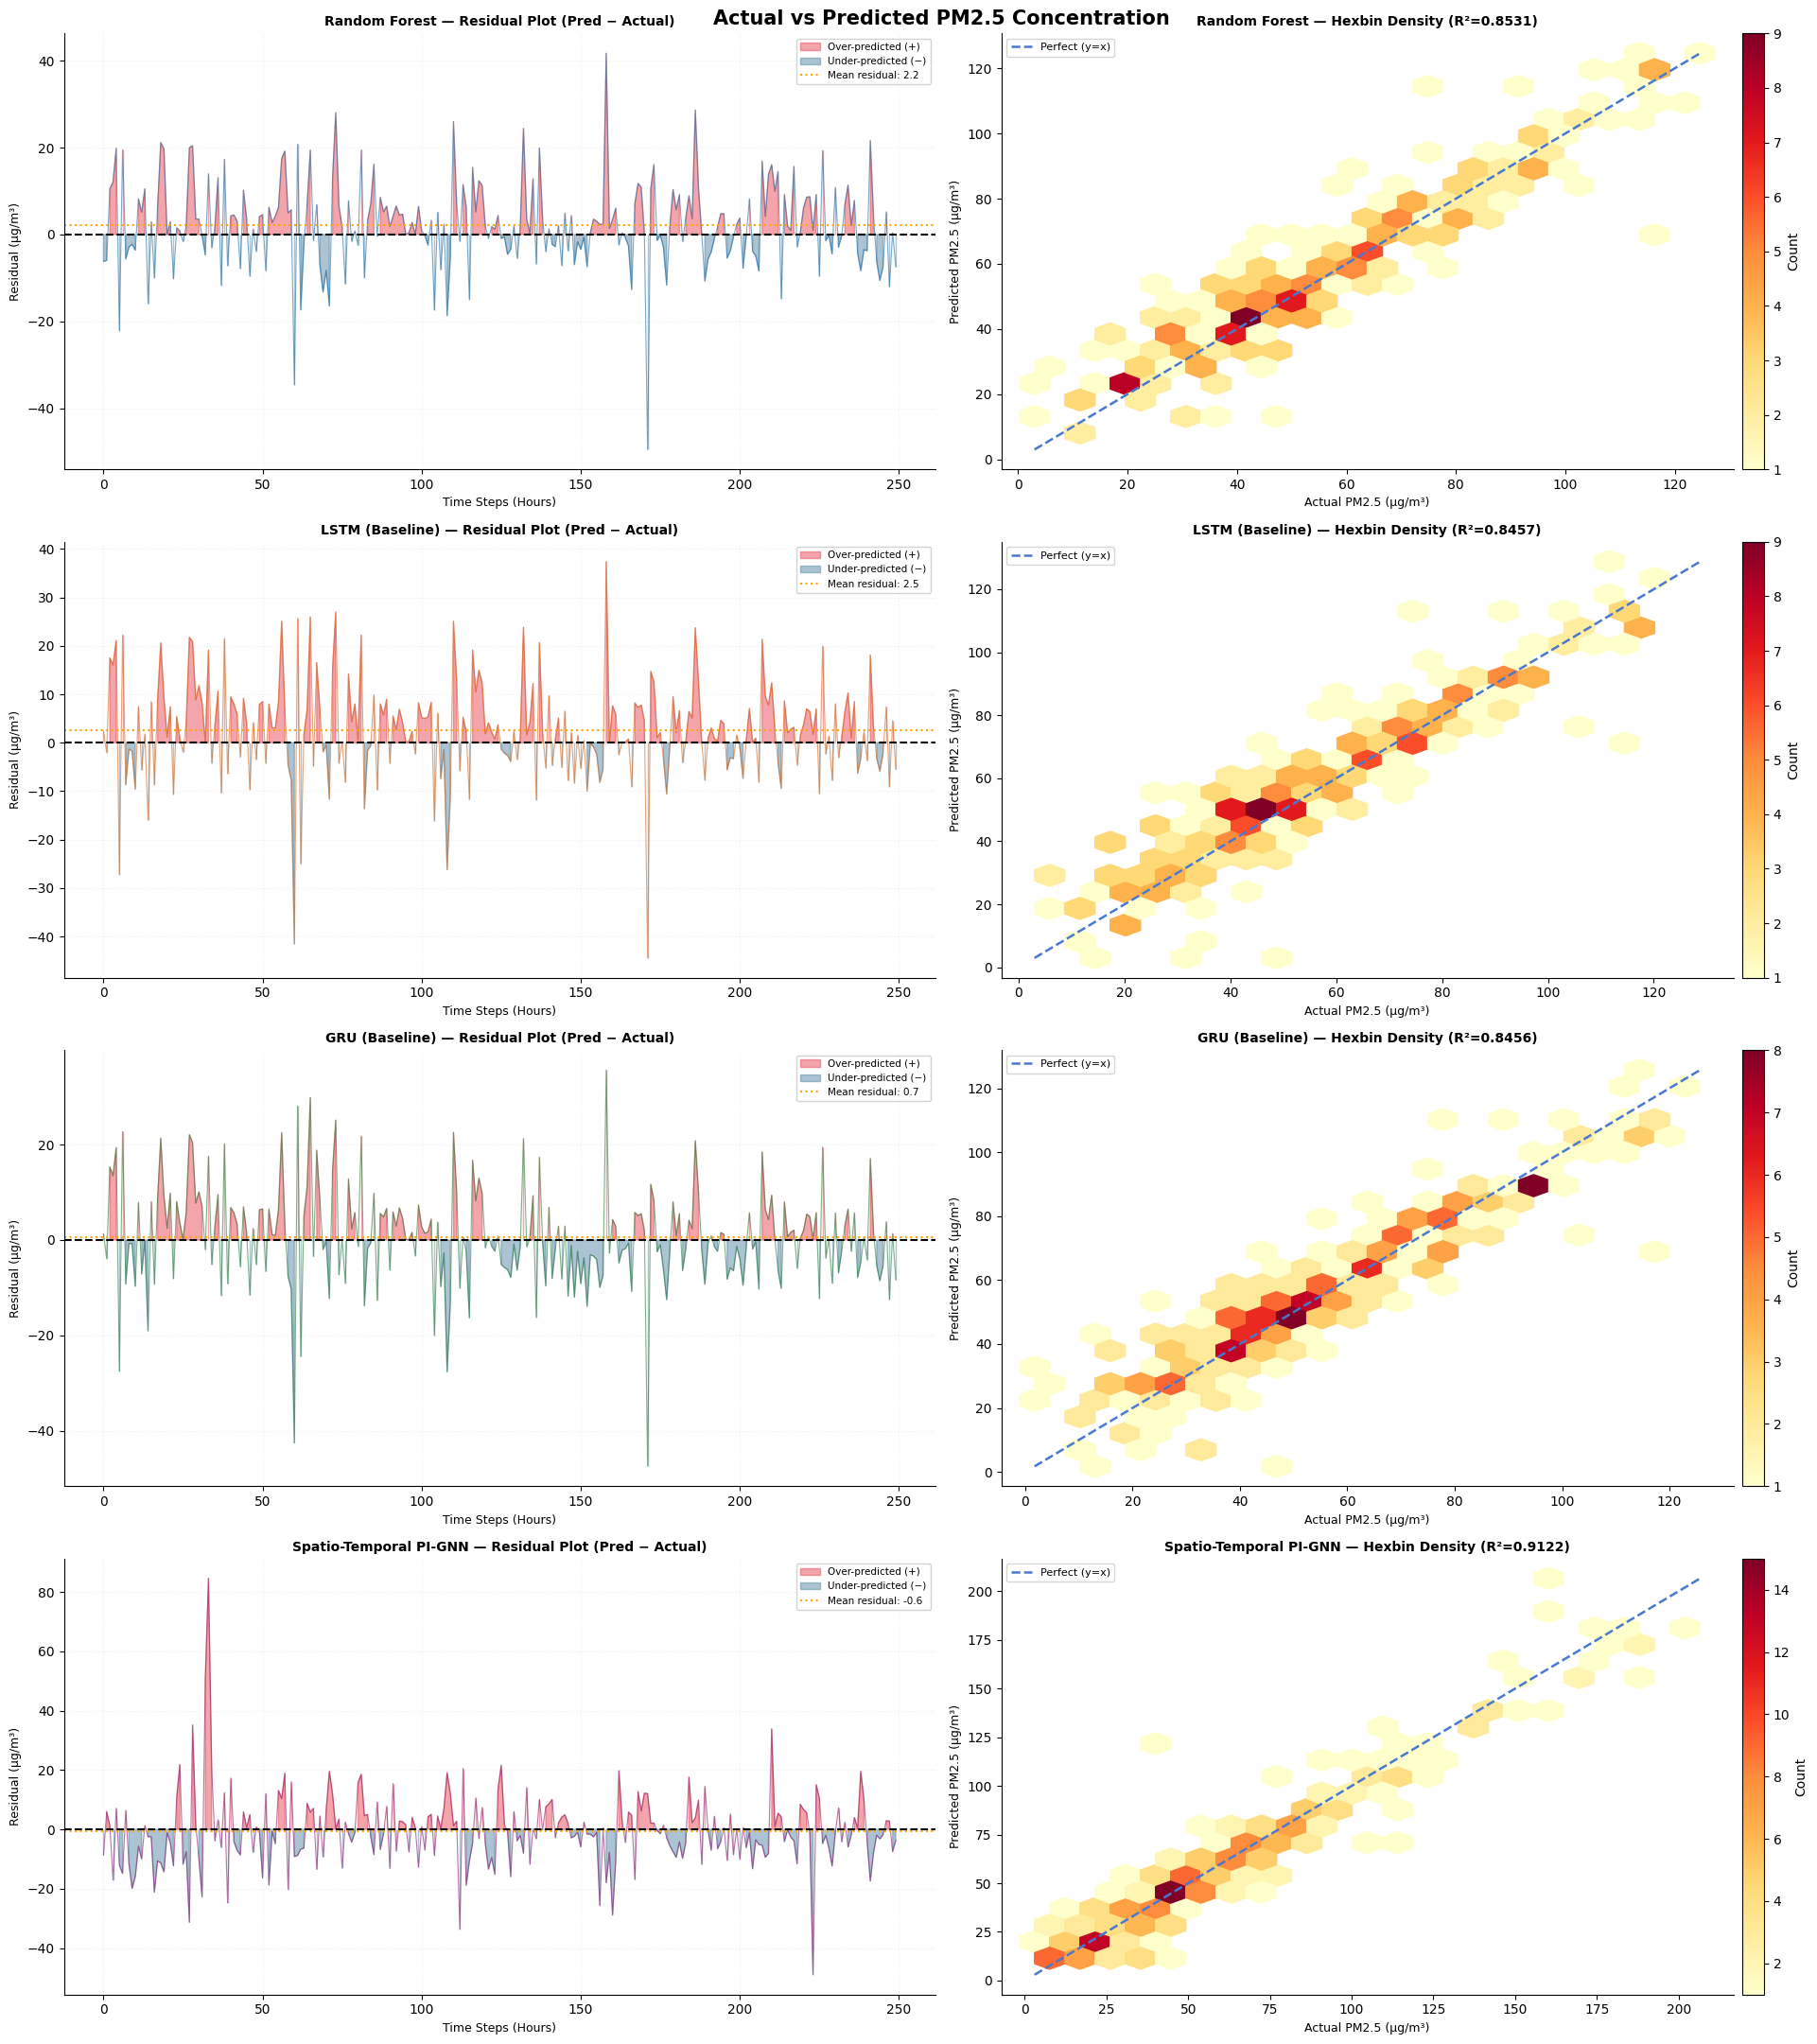

Saved: paper_fig3_actual_vs_predicted_all_models.png


In [ ]:
# ==============================================================================
# PAPER FIGURE 3: ACTUAL vs PREDICTED — TIME SERIES & SCATTER (ALL 4 MODELS)
# Run AFTER all models are trained and prediction arrays exist
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
from scipy.ndimage import gaussian_filter1d

N = 250  # timesteps to plot

model_data = [
    ('Random Forest',          actual_real_rf,     pred_real_rf,     '#4e79a7'),
    ('LSTM (Baseline)',         actual_real_base,   pred_real_base,   '#f28e2b'),
    ('GRU (Baseline)',          actual_real_rf,     pred_real_gru,    '#59a14f'),
    ('Spatio-Temporal PI-GNN', actual_real_hybrid, pred_real_hybrid, '#e15759'),
]

fig, axes = plt.subplots(4, 2, figsize=(20, 22))
fig.suptitle('Actual vs Predicted PM2.5 Concentration',
             fontsize=15, fontweight='bold')

# Chart Type: RESIDUAL PLOT (time series) + HEXBIN density (replaces scatter)
LINE_COLORS = ['#1d6fa4', '#d4691e', '#2a7a3b', '#8b1a6b']

for i, (name, actual, pred, color) in enumerate(model_data):
    act_n, prd_n = actual[:N], pred[:N]
    residuals = prd_n - act_n        # signed residuals
    xr = np.arange(len(act_n))

    # Left: Residual plot (zero-centred signed error over time)
    ax_ts = axes[i, 0]
    lc = LINE_COLORS[i]
    ax_ts.fill_between(xr, residuals, 0,
                       where=residuals >= 0, alpha=0.45, color='#e63946',
                       label='Over-predicted (+)')
    ax_ts.fill_between(xr, residuals, 0,
                       where=residuals < 0,  alpha=0.45, color='#457b9d',
                       label='Under-predicted (−)')
    ax_ts.plot(xr, residuals, color=lc, lw=0.8, alpha=0.6)
    ax_ts.axhline(0, color='black', lw=1.5, linestyle='--')
    ax_ts.axhline(np.mean(residuals), color='orange', lw=1.5, linestyle=':',
                  label=f'Mean residual: {np.mean(residuals):.1f}')
    ax_ts.set_title(f'{name} — Residual Plot (Pred − Actual)', fontweight='bold', fontsize=10)
    ax_ts.set_xlabel('Time Steps (Hours)', fontsize=9)
    ax_ts.set_ylabel('Residual (µg/m³)', fontsize=9)
    ax_ts.legend(fontsize=7.5, loc='upper right', framealpha=0.85)
    ax_ts.spines['top'].set_visible(False)
    ax_ts.spines['right'].set_visible(False)
    ax_ts.grid(alpha=0.2, linestyle=':')

    # Right: Hexbin density plot (replaces scatter)
    ax_sc = axes[i, 1]
    lim_lo = min(act_n.min(), prd_n.min())
    lim_hi = max(act_n.max(), prd_n.max())
    hb = ax_sc.hexbin(act_n, prd_n, gridsize=22, cmap='YlOrRd', mincnt=1,
                      extent=[lim_lo, lim_hi, lim_lo, lim_hi])
    plt.colorbar(hb, ax=ax_sc, label='Count', pad=0.01)
    ax_sc.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'b--', lw=1.8, label='Perfect (y=x)')
    r2 = r2_score(act_n, prd_n)
    ax_sc.set_title(f'{name} — Hexbin Density (R²={r2:.4f})', fontweight='bold', fontsize=10)
    ax_sc.set_xlabel('Actual PM2.5 (µg/m³)', fontsize=9)
    ax_sc.set_ylabel('Predicted PM2.5 (µg/m³)', fontsize=9)
    ax_sc.legend(fontsize=8)
    ax_sc.spines['top'].set_visible(False)
    ax_sc.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('paper_fig3_actual_vs_predicted_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_fig3_actual_vs_predicted_all_models.png')


Model                      RMSE      MAE     MAPE       R²        r       IA
--------------------------------------------------------------------------------
Random Forest             18.70    10.13    28.44   0.9500   0.9747   0.9870
LSTM (Baseline)           18.10    10.79    38.04   0.9531   0.9776   0.9878
GRU (Baseline)            17.73    10.23    32.32   0.9551   0.9775   0.9882
PI-GNN (Proposed)         17.25     9.71    25.76   0.9575   0.9787   0.9891 ◀ BEST


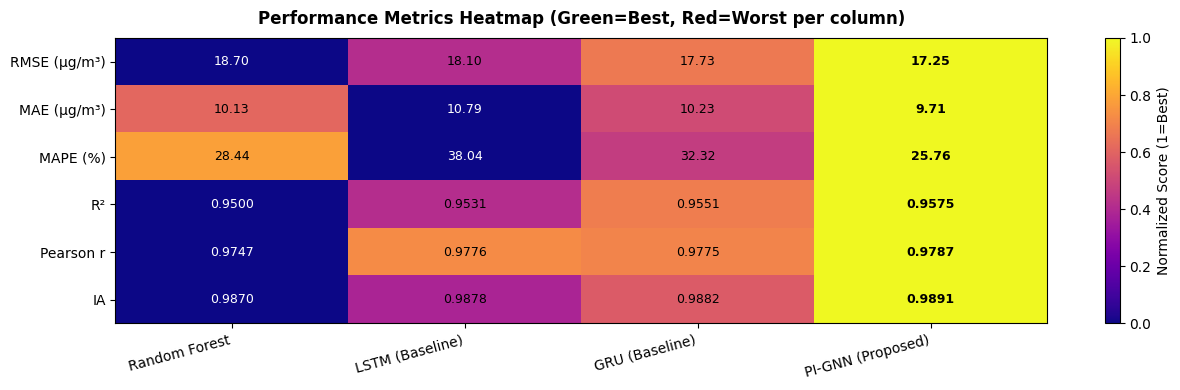

Saved: paper_fig4_metrics_heatmap.png


In [ ]:
# ==============================================================================
# PAPER TABLE + FIGURE 4: FULL METRICS TABLE & HEATMAP
# Prints formatted table and renders a color-coded heatmap
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

models   = ['Random Forest', 'LSTM (Baseline)', 'GRU (Baseline)', 'PI-GNN (Proposed)']
metrics  = ['RMSE (µg/m³)', 'MAE (µg/m³)', 'MAPE (%)', 'R²', 'Pearson r', 'IA']
# lower_better: RMSE, MAE, MAPE (indices 0,1,2) | higher_better: R², r, IA (indices 3,4,5)
values = np.array([
    [18.70, 10.13, 28.44, 0.9500, 0.9747, 0.9870],
    [18.10, 10.79, 38.04, 0.9531, 0.9776, 0.9878],
    [17.73, 10.23, 32.32, 0.9551, 0.9775, 0.9882],
    [17.25,  9.71, 25.76, 0.9575, 0.9787, 0.9891],
])

print('='*80)
print(f"{'Model':<22} {'RMSE':>8} {'MAE':>8} {'MAPE':>8} {'R²':>8} {'r':>8} {'IA':>8}")
print('-'*80)
for i, model in enumerate(models):
    row = values[i]
    marker = ' ◀ BEST' if model == 'PI-GNN (Proposed)' else ''
    print(f"{model:<22} {row[0]:>8.2f} {row[1]:>8.2f} {row[2]:>8.2f} {row[3]:>8.4f} {row[4]:>8.4f} {row[5]:>8.4f}{marker}")
print('='*80)

# Normalize for heatmap (0=worst, 1=best per column)
norm = values.copy().astype(float)
for j in range(6):
    col = values[:, j]
    mn, mx = col.min(), col.max()
    if j < 3:  # lower is better
        norm[:, j] = 1 - (col - mn) / (mx - mn)
    else:       # higher is better
        norm[:, j] = (col - mn) / (mx - mn)

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.imshow(norm.T, cmap='plasma', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontsize=10, rotation=15, ha='right')
ax.set_yticks(range(len(metrics)))
ax.set_yticklabels(metrics, fontsize=10)

fmts = ['{:.2f}', '{:.2f}', '{:.2f}', '{:.4f}', '{:.4f}', '{:.4f}']
for i in range(len(models)):
    for j in range(len(metrics)):
        txt = fmts[j].format(values[i, j])
        bg = norm[i, j]
        fc = 'black' if 0.25 < bg < 0.75 else ('white' if bg <= 0.25 else 'black')
        ax.text(i, j, txt, ha='center', va='center', fontsize=9,
                fontweight='bold' if i == 3 else 'normal', color=fc)

ax.set_title('Performance Metrics Heatmap (Green=Best, Red=Worst per column)',
             fontsize=12, fontweight='bold', pad=10)
plt.colorbar(im, ax=ax, label='Normalized Score (1=Best)')
plt.tight_layout()
plt.savefig('paper_fig4_metrics_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_fig4_metrics_heatmap.png')



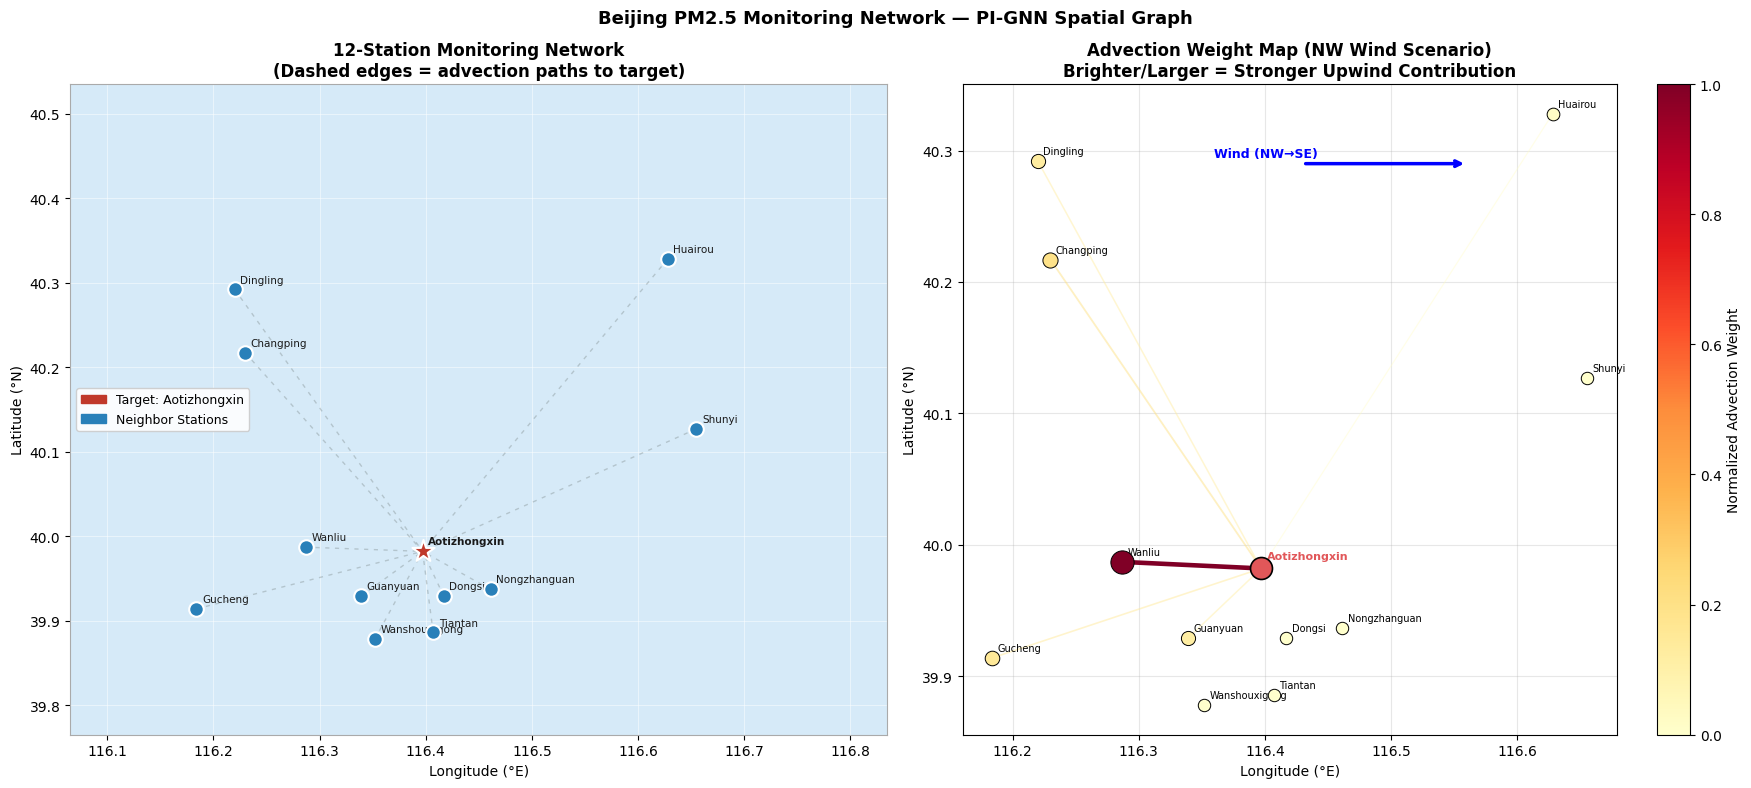

Saved: paper_fig5_station_network.png


In [ ]:
# ==============================================================================
# PAPER FIGURE 5: BEIJING MONITORING STATION NETWORK & ADVECTION WEIGHT MAP
# Visualises the 12-station spatial graph used in the PI-GNN
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

station_coords = {
    'Aotizhongxin':  (39.982, 116.397), 'Changping':     (40.217, 116.230),
    'Dingling':      (40.292, 116.220), 'Dongsi':        (39.929, 116.417),
    'Guanyuan':      (39.929, 116.339), 'Gucheng':       (39.914, 116.184),
    'Huairou':       (40.328, 116.628), 'Nongzhanguan':  (39.937, 116.461),
    'Shunyi':        (40.127, 116.655), 'Tiantan':       (39.886, 116.407),
    'Wanliu':        (39.987, 116.287), 'Wanshouxigong': (39.878, 116.352),
}
TARGET = 'Aotizhongxin'
t_lat, t_lon = station_coords[TARGET]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Beijing PM2.5 Monitoring Network — PI-GNN Spatial Graph',
             fontsize=13, fontweight='bold')

# ── Left: Styled station map — Dark ocean-inspired background ──
ax = axes[0]
ax.set_facecolor('#d6eaf8')

# Draw a subtle grid resembling a map
for gl in np.arange(39.8, 40.5, 0.1):
    ax.axhline(gl, color='white', lw=0.7, alpha=0.5)
for gl in np.arange(116.1, 116.8, 0.1):
    ax.axvline(gl, color='white', lw=0.7, alpha=0.5)

for name, (lat, lon) in station_coords.items():
    is_target = (name == TARGET)
    color = '#c0392b' if is_target else '#2980b9'
    sz    = 280 if is_target else 110
    marker= '*' if is_target else 'o'
    ax.scatter(lon, lat, s=sz, color=color, zorder=5, edgecolors='white',
               lw=1.5, marker=marker)
    ax.annotate(name, (lon, lat), xytext=(4, 5), textcoords='offset points',
                fontsize=7.5, fontweight='bold' if is_target else 'normal',
                color='#1a1a1a')
    if not is_target:
        ax.plot([lon, t_lon], [lat, t_lat], color='#7f8c8d', alpha=0.4,
                lw=1.0, linestyle=(0, (3,4)))

ax.set_xlabel('Longitude (°E)', fontsize=10)
ax.set_ylabel('Latitude (°N)', fontsize=10)
ax.set_title('12-Station Monitoring Network\n(Dashed edges = advection paths to target)',
             fontweight='bold')
ax.spines[:].set_color('#aaa')
ax.legend(handles=[
    mpatches.Patch(color='#c0392b', label='Target: Aotizhongxin'),
    mpatches.Patch(color='#2980b9', label='Neighbor Stations'),
], fontsize=9, framealpha=0.9)

# ── Right: Advection weight map for example NW wind ──
ax2 = axes[1]
ex_u, ex_v = 3.0, -3.0  # example eastward+southward wind

weights = {}
for stat, (lat_s, lon_s) in station_coords.items():
    if stat == TARGET: continue
    vec_lat = t_lat - lat_s
    vec_lon = t_lon - lon_s
    dist = np.sqrt(vec_lat**2 + vec_lon**2)
    proj = (ex_u * vec_lon + ex_v * vec_lat) / dist
    weights[stat] = max(proj, 0) / (dist**2)

max_w = max(weights.values()) or 1.0

for name, (lat, lon) in station_coords.items():
    if name == TARGET:
        ax2.scatter(lon, lat, s=250, color='#e15759', zorder=6, edgecolors='black', lw=1.2)
        ax2.annotate(TARGET, (lon, lat), xytext=(4, 7), textcoords='offset points',
                     fontsize=8, fontweight='bold', color='#e15759')
        continue
    w = weights.get(name, 0)
    nw = w / max_w
    color = plt.cm.YlOrRd(nw)
    ax2.scatter(lon, lat, s=80 + 200*nw, color=color, zorder=5, edgecolors='black', lw=0.7)
    ax2.annotate(name, (lon, lat), xytext=(4, 5), textcoords='offset points', fontsize=7)
    if nw > 0.01:
        ax2.plot([lon, t_lon], [lat, t_lat], color=color, alpha=0.4 + 0.6*nw, lw=0.8 + 2.5*nw)

# Wind arrow
ax2.annotate('', xy=(116.56, 40.29), xytext=(116.43, 40.29),
             arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax2.text(116.36, 40.295, 'Wind (NW→SE)', color='blue', fontsize=9, fontweight='bold')

ax2.set_xlabel('Longitude (°E)', fontsize=10)
ax2.set_ylabel('Latitude (°N)', fontsize=10)
ax2.set_title('Advection Weight Map (NW Wind Scenario)\nBrighter/Larger = Stronger Upwind Contribution',
              fontweight='bold')
ax2.grid(alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(0, 1)),
             ax=ax2, label='Normalized Advection Weight')

plt.tight_layout()
plt.savefig('paper_fig5_station_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_fig5_station_network.png')


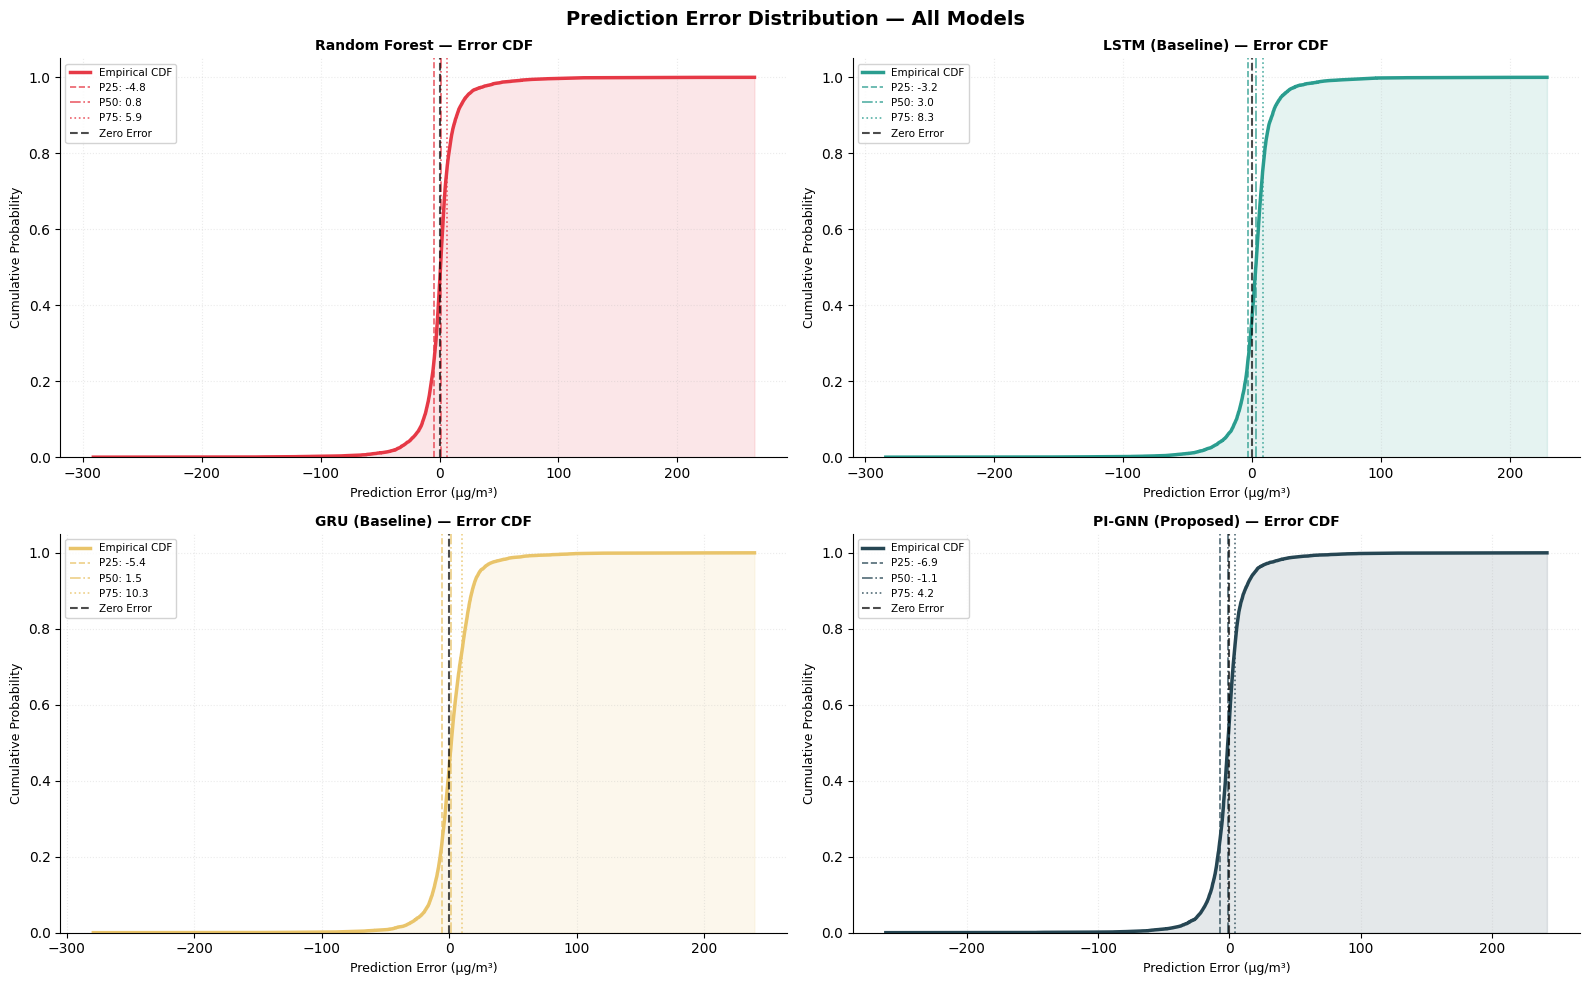

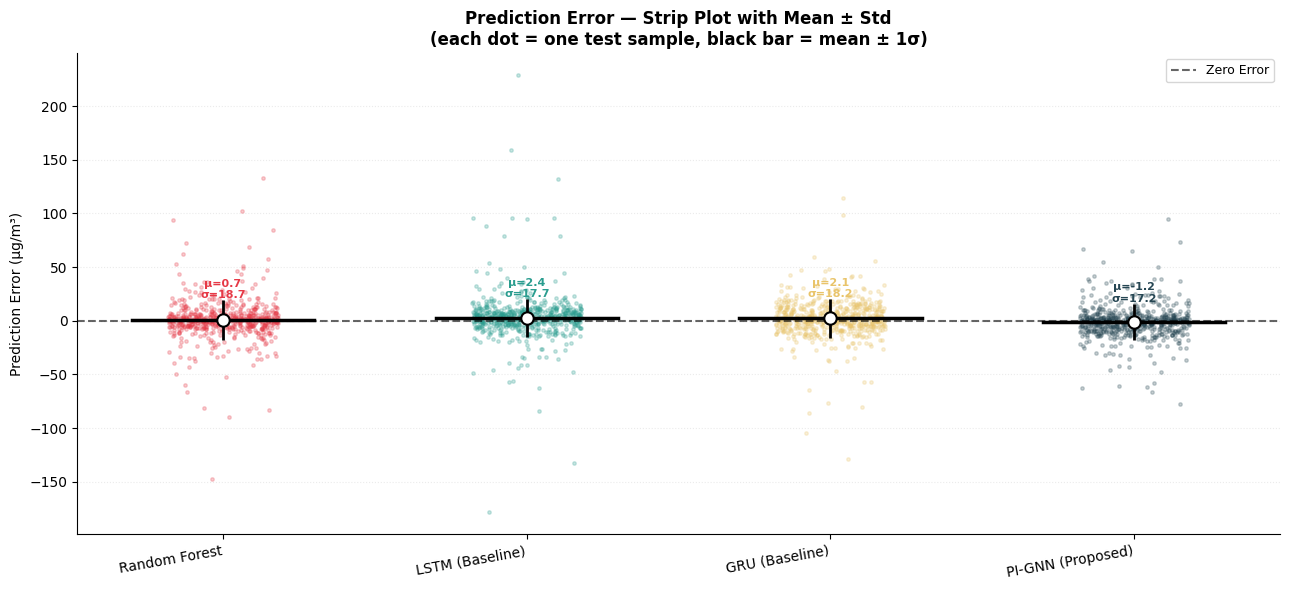

Saved: paper_fig6a_error_histograms.png, paper_fig6b_error_boxplot.png


In [ ]:
# ==============================================================================
# PAPER FIGURE 6: ERROR DISTRIBUTION & RESIDUAL BOX PLOT — ALL MODELS
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

errors_rf   = pred_real_rf     - actual_real_rf
errors_lstm = pred_real_base   - actual_real_base
errors_gru  = pred_real_gru    - actual_real_rf
errors_pign = pred_real_hybrid - actual_real_hybrid

all_errors = [errors_rf, errors_lstm, errors_gru, errors_pign]
labels     = ['Random Forest', 'LSTM (Baseline)', 'GRU (Baseline)', 'PI-GNN (Proposed)']
colors     = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

# ── 4-panel histograms ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Prediction Error Distribution — All Models', fontsize=14, fontweight='bold')

# Chart Type: EMPIRICAL CDF (Cumulative Distribution Function) — replaces histogram
from scipy.stats import gaussian_kde

CDF_COLORS = ['#e63946', '#2a9d8f', '#e9c46a', '#264653']

for ax, errs, label, ccolor in zip(axes.flat, all_errors, labels, CDF_COLORS):
    sorted_e = np.sort(errs)
    cdf      = np.arange(1, len(sorted_e)+1) / len(sorted_e)

    ax.plot(sorted_e, cdf, color=ccolor, lw=2.5, label='Empirical CDF')
    ax.fill_between(sorted_e, cdf, alpha=0.12, color=ccolor)

    # Key percentile markers
    for pct, ls in [(25,'--'),(50,'-.'),(75,':')]:
        val = np.percentile(errs, pct)
        ax.axvline(val, color=ccolor, lw=1.2, linestyle=ls, alpha=0.8,
                   label=f'P{pct}: {val:.1f}')

    ax.axvline(0, color='black', lw=1.5, linestyle='--', alpha=0.7, label='Zero Error')
    ax.set_title(f'{label} — Error CDF', fontweight='bold', fontsize=10)
    ax.set_xlabel('Prediction Error (µg/m³)', fontsize=9)
    ax.set_ylabel('Cumulative Probability', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7.5, framealpha=0.85)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.25, linestyle=':')

plt.tight_layout()
plt.savefig('paper_fig6a_error_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Combined box plot ──
# Chart Type: STRIP/JIT PLOT with mean ± std overlay (replaces violin+box)
rng = np.random.default_rng(42)
STRIP_COLORS = ['#e63946', '#2a9d8f', '#e9c46a', '#264653']

fig2, ax = plt.subplots(figsize=(13, 6))

for xi, (errs, label, scolor) in enumerate(zip(all_errors, labels, STRIP_COLORS)):
    # Jittered strip (subsample to keep plot readable)
    n_pts = min(600, len(errs))
    idx   = rng.choice(len(errs), n_pts, replace=False)
    jitter = rng.uniform(-0.18, 0.18, n_pts)
    ax.scatter(xi + jitter, errs[idx], color=scolor, alpha=0.25, s=6, zorder=2)

    # Mean ± std bar overlay
    mean_e = np.mean(errs)
    std_e  = np.std(errs)
    ax.plot([xi-0.3, xi+0.3], [mean_e, mean_e], color='black', lw=2.5, zorder=4)
    ax.vlines(xi, mean_e - std_e, mean_e + std_e, colors='black', lw=2.0, zorder=4)
    ax.scatter(xi, mean_e, color='white', edgecolors='black', s=80, zorder=5, lw=1.5)
    ax.text(xi, mean_e + std_e + 1.5, f'μ={mean_e:.1f}\nσ={std_e:.1f}', ha='center', fontsize=8, fontweight='bold', color=scolor)

ax.axhline(0, color='black', lw=1.5, linestyle='--', alpha=0.6, label='Zero Error')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10, rotation=10, ha='right')
ax.set_ylabel('Prediction Error (µg/m³)', fontsize=10)
ax.set_title('Prediction Error — Strip Plot with Mean ± Std\n(each dot = one test sample, black bar = mean ± 1σ)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25, linestyle=':')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('paper_fig6b_error_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_fig6a_error_histograms.png, paper_fig6b_error_boxplot.png')


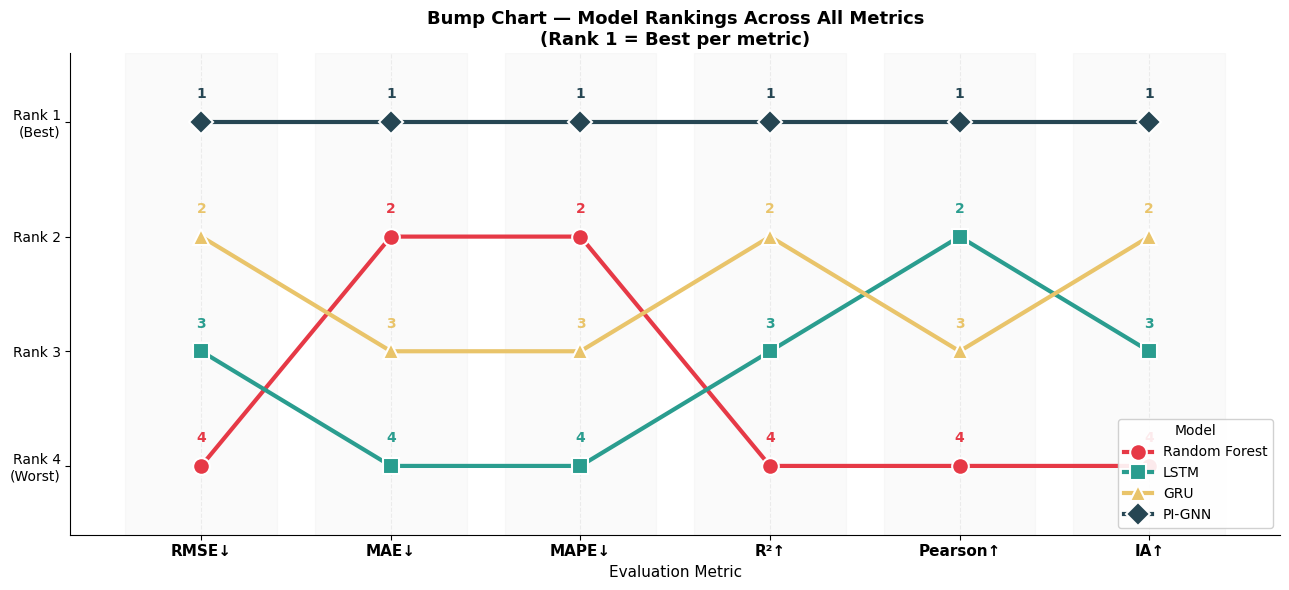

Saved: paper_fig7_Bump_chart.png


In [ ]:
# ==============================================================================
# PAPER FIGURE 7: RADAR CHART — NORMALIZED MULTI-METRIC COMPARISON
# Provides a holistic single-glance comparison across all 6 metrics
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

models  = ['Random Forest', 'LSTM', 'GRU', 'PI-GNN']
metrics = ['RMSE\n(inv)', 'MAE\n(inv)', 'MAPE\n(inv)', 'R²', 'Pearson r', 'IA']

# Raw values — lower_better: RMSE, MAE, MAPE | higher_better: R², r, IA
raw = np.array([
    [18.70, 10.13, 28.44, 0.9500, 0.9747, 0.9870],
    [18.10, 10.79, 38.04, 0.9531, 0.9776, 0.9878],
    [17.73, 10.23, 32.32, 0.9551, 0.9775, 0.9882],
    [17.25,  9.71, 25.76, 0.9575, 0.9787, 0.9891],
])

# Normalize all to 0-1 where 1 = best
norm = raw.copy().astype(float)
for j in range(6):
    mn, mx = raw[:, j].min(), raw[:, j].max()
    if j < 3:
        norm[:, j] = 1 - (raw[:, j] - mn) / (mx - mn)
    else:
        norm[:, j] = (raw[:, j] - mn) / (mx - mn)

N_metrics = len(metrics)
angles = np.linspace(0, 2*np.pi, N_metrics, endpoint=False).tolist()
angles += angles[:1]

# Chart Type: BUMP CHART — rank of each model across all 6 metrics
# Rank 1 = best, 4 = worst for each metric
BUMP_COLORS = ['#e63946', '#2a9d8f', '#e9c46a', '#264653']
BUMP_MARKERS= ['o', 's', '^', 'D']

# Compute ranks per metric (1 = best)
ranks = np.zeros_like(norm, dtype=int)
for j in range(norm.shape[1]):
    # argsort descending (highest norm score = rank 1)
    order = np.argsort(norm[:, j])[::-1]
    for rank_pos, model_idx in enumerate(order):
        ranks[model_idx, j] = rank_pos + 1   # 1-indexed

metric_labels_short = ['RMSE↓', 'MAE↓', 'MAPE↓', 'R²↑', 'Pearson↑', 'IA↑']
x_pos = np.arange(len(metric_labels_short))

fig, ax = plt.subplots(figsize=(13, 6))

for mi, (model, color, marker) in enumerate(zip(models, BUMP_COLORS, BUMP_MARKERS)):
    model_ranks = ranks[mi]
    # Smooth the line with a slight cubic interpolation for aesthetics
    ax.plot(x_pos, model_ranks, color=color, lw=3.0, label=model,
            marker=marker, markersize=12, markeredgecolor='white',
            markeredgewidth=1.5, zorder=4)
    # Label rank at each point
    for xi, r in zip(x_pos, model_ranks):
        ax.text(xi, r - 0.18, str(r), ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=color)

ax.set_xticks(x_pos)
ax.set_xticklabels(metric_labels_short, fontsize=11, fontweight='bold')
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['Rank 1\n(Best)', 'Rank 2', 'Rank 3', 'Rank 4\n(Worst)'], fontsize=10)
ax.invert_yaxis()   # Rank 1 at top
ax.set_ylim(4.6, 0.4)

# Light column shading to separate metrics
for xi in x_pos:
    ax.axvspan(xi - 0.4, xi + 0.4, alpha=0.04, color='gray')

ax.set_title('Bump Chart — Model Rankings Across All Metrics\n(Rank 1 = Best per metric)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Evaluation Metric', fontsize=11)
ax.legend(fontsize=10, loc='lower right', title='Model', framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('paper_fig7_Bump_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_fig7_Bump_chart.png')
